In [3]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "4"

import torch
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Number of visible GPUs: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"Device {i}: {torch.cuda.get_device_name(i)}")

1
NVIDIA L40S
CUDA available: True
Number of visible GPUs: 1
Device 0: NVIDIA L40S


In [1]:
# ============================================================================
# IMPORTS
# ============================================================================

import cv2
import numpy as np
import random
import torch
import torch.nn as nn
import gc
import os
import pandas as pd
import hashlib
from tqdm import tqdm
from torchvision import models, transforms
from torchvision.models import ResNet50_Weights
from PIL import Image
import json
import time
from datetime import datetime
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc as sklearn_auc, classification_report

In [3]:
# ============================================================================
# CONFIGURATION
# ============================================================================

ROOT_PATH  = "/home/rmuthy2/central_data/datasets/internal/EmoryCXRv2/ORIGINAL_PNG"
TRAIN_CSV  = "/home/rmuthy2/Machine-Induced Noise/train.csv"
TEST_CSV   = "/home/rmuthy2/Machine-Induced Noise/test.csv"
OUTPUT_DIR = "/home/rmuthy2/Machine-Induced Noise/Localized_Blur_64px__ResNet50"

GRID_SIZE      = 8          # 4×4 grid of pixels
PIXEL_SPACING  = 1          # 4 pixels between each grid point
BLUR_KSIZE     = 21         # Gaussian kernel applied around each pixel (must be odd)
BLUR_SIGMA     = 0          # Auto-selected by OpenCV

# Grid placement: centered with margin
PLACEMENT_MARGIN = 0.20     # 20% margin from edges

# ResNet-50 training
TARGET_SIZE    = (448, 448) # Input size for ResNet-50
BATCH_SIZE     = 16
EPOCHS         = 10
LEARNING_RATE  = 1e-4

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [6]:
# ============================================================================
# IMAGE PREPROCESSOR
# ============================================================================

class ImagePreprocessor:
    def __init__(self, square_size=3052, target_size=(448, 448)):
        self.square_size = square_size
        self.target_size = target_size
    
    def pad_to_square_and_resize(self, image_path):
        image = cv2.imread(image_path)
        if image is None:
            raise ValueError(f"Cannot load: {image_path}")
        
        h, w = image.shape[:2]
        max_dim = max(h, w, self.square_size)
        
        pad_h = max_dim - h
        pad_w = max_dim - w
        top, bottom = pad_h // 2, pad_h - pad_h // 2
        left, right = pad_w // 2, pad_w - pad_w // 2
        
        if len(image.shape) == 3:
            padded = cv2.copyMakeBorder(image, top, bottom, left, right,
                                       cv2.BORDER_CONSTANT, value=[0, 0, 0])
        else:
            padded = cv2.copyMakeBorder(image, top, bottom, left, right,
                                       cv2.BORDER_CONSTANT, value=0)
        
        resized = cv2.resize(padded, self.target_size, interpolation=cv2.INTER_LANCZOS4)
        return resized

In [7]:
# ============================================================================
# LOCALIZED BLUR INJECTOR — 4×4 GRID (16 PIXELS TOTAL)
# ============================================================================

class LocalizedBlurInjector_Grid:
    """
    Injects a 4×4 grid of blurred pixels (16 total pixels).
    
    Each pixel in the 4×4 grid gets a blur kernel applied around it.
    This creates 16 tiny localized blur spots that simulate micro-calcifications
    at the smallest detectable scale.
    
    Clinical rationale:
    - 16 pixels = absolute minimum for micro-calcification detection
    - 4×4 arrangement = compact cluster (like calcification clustering)
    - Tests whether CNNs can detect ultra-fine-grained artifacts
    """
    
    def __init__(self, seed=42):
        self.seed = seed
    
    def _get_deterministic_seed(self, image_path):
        filename = os.path.basename(image_path)
        seed_string = f"{self.seed}_{filename}"
        hash_object = hashlib.sha256(seed_string.encode())
        return int(hash_object.hexdigest()[:8], 16)
    
    def add_localized_blur_grid(
        self,
        image,
        pixel_spacing=PIXEL_SPACING,
        blur_ksize=BLUR_KSIZE,
        blur_sigma=BLUR_SIGMA,
        margin=PLACEMENT_MARGIN,
        image_path=None
    ):
        """
        Apply localized Gaussian blur to a 4×4 grid of individual pixels.
        
        Parameters
        ----------
        image : np.ndarray  H×W or H×W×C uint8
        pixel_spacing : int  Pixels between each grid point (default: 4)
        blur_ksize : int     Gaussian kernel size around each pixel (must be odd)
        blur_sigma : float   Gaussian sigma (0 = auto)
        margin : float       Margin from image edges (0.20 = 20%)
        image_path : str     Used for deterministic RNG seeding
        
        Returns
        -------
        noisy : np.ndarray  Same shape/dtype as image
        meta : dict         Grid locations and parameters
        """
        seed = self._get_deterministic_seed(image_path) if image_path else self.seed
        rng  = np.random.default_rng(seed)
        
        noisy = image.copy()
        h, w  = image.shape[:2]
        
        # Pre-blur the entire image once
        blurred_full = cv2.GaussianBlur(image, (blur_ksize, blur_ksize), blur_sigma)
        
        # Define safe anatomical region
        margin_h = int(h * margin)
        margin_w = int(w * margin)
        
        # Calculate 4×4 grid size
        grid_size = GRID_SIZE
        total_grid_h = (grid_size - 1) * pixel_spacing  # e.g., 3 * 4 = 12 pixels tall
        total_grid_w = (grid_size - 1) * pixel_spacing  # e.g., 3 * 4 = 12 pixels wide
        
        # Randomly place the top-left corner of the 4×4 grid in the safe region
        max_y = h - margin_h - total_grid_h - blur_ksize // 2
        max_x = w - margin_w - total_grid_w - blur_ksize // 2
        
        start_y = rng.integers(margin_h, max(margin_h + 1, max_y))
        start_x = rng.integers(margin_w, max(margin_w + 1, max_x))
        
        pixel_locations = []
        half_kernel = blur_ksize // 2
        
        # Create 4×4 grid of blurred pixels
        for row in range(grid_size):
            for col in range(grid_size):
                pixel_y = start_y + row * pixel_spacing
                pixel_x = start_x + col * pixel_spacing
                
                # Apply blur around this pixel (blur_ksize × blur_ksize region)
                y1 = max(0, pixel_y - half_kernel)
                y2 = min(h, pixel_y + half_kernel + 1)
                x1 = max(0, pixel_x - half_kernel)
                x2 = min(w, pixel_x + half_kernel + 1)
                
                noisy[y1:y2, x1:x2] = blurred_full[y1:y2, x1:x2]
                pixel_locations.append({'row': row, 'col': col, 'y': pixel_y, 'x': pixel_x})
        
        noisy = np.clip(noisy, 20, 235).astype(np.uint8)
        
        meta = {
            'grid_size': grid_size,
            'num_pixels': len(pixel_locations),
            'pixel_spacing': pixel_spacing,
            'blur_ksize': blur_ksize,
            'grid_top_left': (start_y, start_x),
            'pixel_locations': pixel_locations
        }
        return noisy, meta

In [8]:
# ============================================================================
# DATASET CLASS
# ============================================================================

class CXRDataset(Dataset):
    def __init__(self, df, preprocessor, injector, root_path, transform=None, is_test=False):
        self.df = df.reset_index(drop=True)
        self.preprocessor = preprocessor
        self.injector = injector
        self.root_path = root_path
        self.transform = transform
        self.is_test = is_test
    
    def __len__(self):
        return len(self.df) * 2  # clean + noisy per image
    
    def __getitem__(self, idx):
        image_idx = idx // 2
        is_noisy = idx % 2
        
        row = self.df.iloc[image_idx]
        img_path = os.path.join(self.root_path, row['ImagePath'])
        
        try:
            processed = self.preprocessor.pad_to_square_and_resize(img_path)
            
            if is_noisy:
                noisy, _ = self.injector.add_localized_blur_grid(
                    processed,
                    image_path=img_path
                )
                final_img = noisy
                label = 1
            else:
                final_img = processed
                label = 0
            
            # Convert BGR → RGB
            if len(final_img.shape) == 3:
                final_img = cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB)
            else:
                final_img = cv2.cvtColor(final_img, cv2.COLOR_GRAY2RGB)
            
            pil_img = Image.fromarray(final_img)
            
            if self.transform:
                pil_img = self.transform(pil_img)
            
            return pil_img, label
            
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            # Return a black image as fallback
            fallback = torch.zeros(3, 448, 448)
            return fallback, 0

In [9]:
# ============================================================================
# RESNET-50 MODEL
# ============================================================================

def create_resnet50_model():
    """
    Create ResNet-50 with ImageNet pre-trained weights.
    Replace final FC layer for binary classification.
    """
    model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
    
    # Replace final layer: 2048 → 2 (clean vs noisy)
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 2)
    
    return model

In [10]:
# ============================================================================
# TRAINING & EVALUATION FUNCTIONS
# ============================================================================

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(dataloader, desc="Training"):
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Evaluating"):
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_probs.extend(probs[:, 1].cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(all_labels)
    epoch_acc = sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)
    
    return epoch_loss, epoch_acc, all_probs, all_labels

In [11]:
# ============================================================================
# CHECKPOINT MANAGER
# ============================================================================

class CheckpointManager:
    def __init__(self, output_dir):
        self.output_dir = output_dir
        self.checkpoint_path = os.path.join(output_dir, 'best_model.pth')
        self.history_path = os.path.join(output_dir, 'training_history.json')
        self.best_auc = 0.0
    
    def save_checkpoint(self, model, epoch, auc, history):
        if auc > self.best_auc:
            self.best_auc = auc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'auc': auc,
            }, self.checkpoint_path)
            print(f"✓ Saved best model (AUC: {auc:.4f})")
        
        with open(self.history_path, 'w') as f:
            json.dump(history, f, indent=2)
    
    def load_checkpoint(self, model):
        if os.path.exists(self.checkpoint_path):
            checkpoint = torch.load(self.checkpoint_path)
            model.load_state_dict(checkpoint['model_state_dict'])
            print(f"✓ Loaded checkpoint from epoch {checkpoint['epoch']} (AUC: {checkpoint['auc']:.4f})")
            return checkpoint['epoch']
        return 0

In [12]:
# ============================================================================
# MAIN TRAINING PIPELINE
# ============================================================================

if __name__ == "__main__":
 
    print(f"Total pixels : {GRID_SIZE}")
    print(f"Pixel spacing: {PIXEL_SPACING} pixels")
    print(f"Blur kernel  : {BLUR_KSIZE}×{BLUR_KSIZE} Gaussian (applied around each pixel)")
    print(f"Epochs       : {EPOCHS}")
    print(f"Batch size   : {BATCH_SIZE}")
    print(f"Output       : {OUTPUT_DIR}")
    print(f"{'='*70}\n")
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}\n")
    
    # Data transforms
    train_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=5),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Load data
    print("Loading datasets...")
    train_df = pd.read_csv(TRAIN_CSV)
    test_df = pd.read_csv(TEST_CSV)
    print(f"Train: {len(train_df)} images, Test: {len(test_df)} images\n")
    
    # Initialize components
    preprocessor = ImagePreprocessor(target_size=TARGET_SIZE)
    injector = LocalizedBlurInjector_Grid(seed=42)
    
    train_dataset = CXRDataset(train_df, preprocessor, injector, ROOT_PATH, 
                                transform=train_transform, is_test=False)
    test_dataset = CXRDataset(test_df, preprocessor, injector, ROOT_PATH,
                               transform=test_transform, is_test=True)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
    
    # Create model
    print("Initializing ResNet-50...")
    model = create_resnet50_model().to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    checkpoint_mgr = CheckpointManager(OUTPUT_DIR)
    
    # Training history
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [], 'val_auc': []
    }
    
    # Training loop
    print(f"\nStarting training for {EPOCHS} epochs...\n")
    for epoch in range(1, EPOCHS + 1):
        print(f"\n{'='*70}")
        print(f"Epoch {epoch}/{EPOCHS}")
        print(f"{'='*70}")
        
        # Train
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        
        # Evaluate
        val_loss, val_acc, val_probs, val_labels = evaluate(model, test_loader, criterion, device)
        
        # Calculate AUC
        fpr, tpr, _ = roc_curve(val_labels, val_probs)
        val_auc = sklearn_auc(fpr, tpr)
        
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val AUC: {val_auc:.4f}")
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_auc'].append(val_auc)
        
        # Save checkpoint
        checkpoint_mgr.save_checkpoint(model, epoch, val_auc, history)
        
        # Memory cleanup
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()
    
    print(f"\n{'='*70}")
    print("✅ TRAINING COMPLETE!")
    print(f"Best AUC: {checkpoint_mgr.best_auc:.4f}")
    print(f"Results saved to: {OUTPUT_DIR}")
    print(f"{'='*70}\n")

Total pixels : 8
Pixel spacing: 1 pixels
Blur kernel  : 21×21 Gaussian (applied around each pixel)
Epochs       : 10
Batch size   : 16
Output       : /home/rmuthy2/Machine-Induced Noise/Localized_Blur_64px__ResNet50

Using device: cuda

Loading datasets...
Train: 109824 images, Test: 27456 images

Initializing ResNet-50...

Starting training for 10 epochs...


Epoch 1/10


Training:   0%|          | 5/13728 [00:05<4:10:46,  1.10s/it] 


KeyboardInterrupt: 

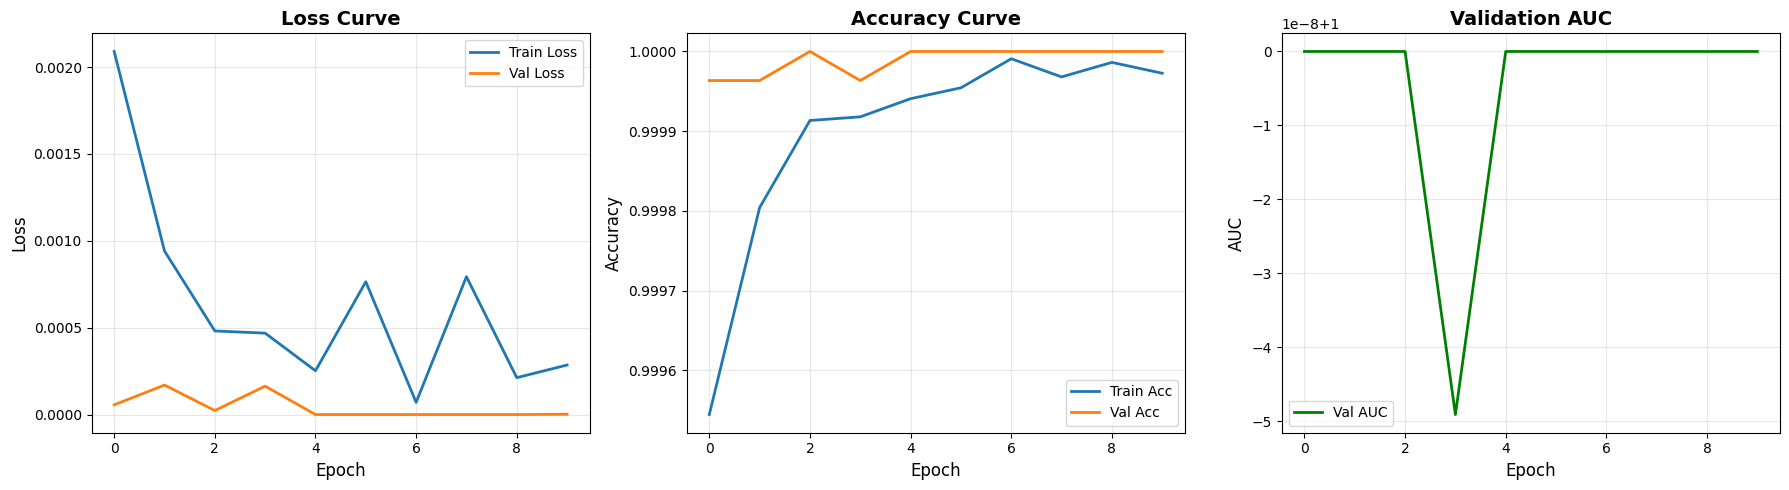


✓ Training curves saved to /home/rmuthy2/Machine-Induced Noise/Localized_Blur_64px__ResNet50/training_curves.png


In [4]:
# ============================================================================
# PLOT TRAINING HISTORY
# ============================================================================

with open(os.path.join(OUTPUT_DIR, 'training_history.json'), 'r') as f:
    history = json.load(f)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Loss Curve', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history['train_acc'], label='Train Acc', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Acc', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Accuracy Curve', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# AUC
axes[2].plot(history['val_auc'], label='Val AUC', linewidth=2, color='green')
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('AUC', fontsize=12)
axes[2].set_title('Validation AUC', fontsize=14, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✓ Training curves saved to {OUTPUT_DIR}/training_curves.png")


Loading best model for final evaluation...
✓ Best model loaded successfully.


Evaluating: 100%|██████████| 3432/3432 [33:02<00:00,  1.73it/s]



FINAL TEST SET RESULTS
Test Accuracy:  1.0000
Test AUC:       1.0000
Best Threshold: 0.9890

Classification Report:
              precision    recall  f1-score   support

       Clean     1.0000    1.0000    1.0000     27456
       Noisy     1.0000    1.0000    1.0000     27456

    accuracy                         1.0000     54912
   macro avg     1.0000    1.0000    1.0000     54912
weighted avg     1.0000    1.0000    1.0000     54912

Confusion Matrix:
[[27456     0]
 [    0 27456]]



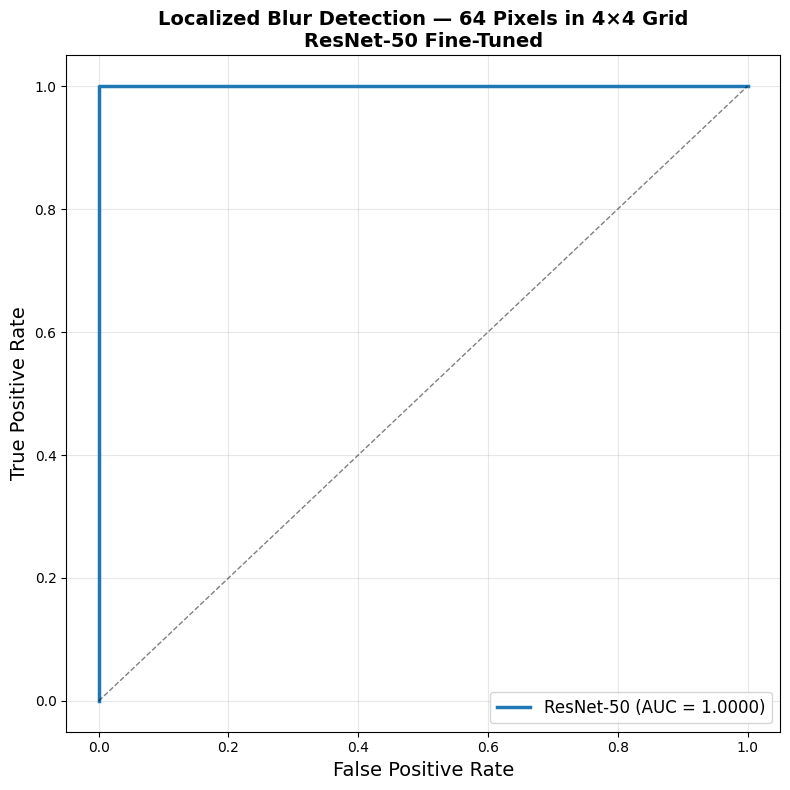

✓ ROC curve saved to outputs/final_roc_curve.png

Loading training history...


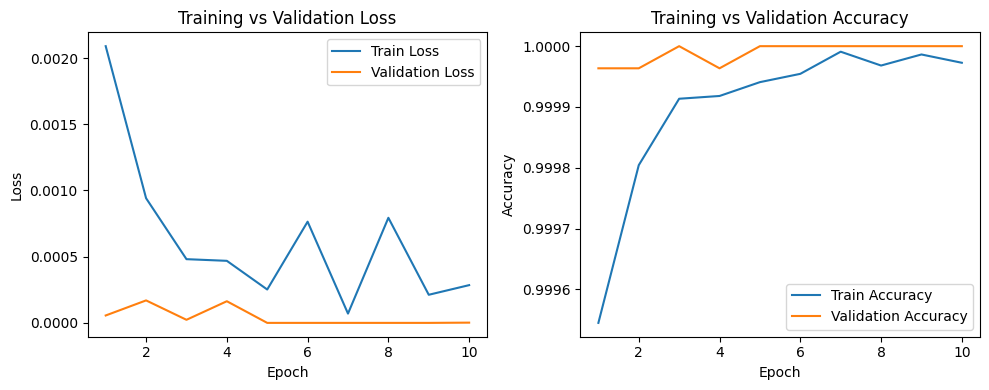

✓ Training curves saved to outputs/training_curves.png


In [16]:
# ============================================================================
# FINAL EVALUATION ON TEST SET
# ============================================================================

import torch
import json
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.metrics import (
    classification_report,
    roc_curve,
    auc as sklearn_auc,
    confusion_matrix
)

print("\nLoading best model for final evaluation...")

# --------------------------------------------------------------------------
# Load Best Model
# --------------------------------------------------------------------------
model = create_resnet50_model().to(device)

checkpoint = torch.load("/home/rmuthy2/Machine-Induced Noise/Localized_Blur_64px__ResNet50/best_model.pth", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("✓ Best model loaded successfully.")

# --------------------------------------------------------------------------
# Evaluate on Test Set
# --------------------------------------------------------------------------
_, test_acc, test_probs, test_labels = evaluate(
    model, test_loader, criterion, device
)

test_probs = np.array(test_probs)
test_labels = np.array(test_labels)

# --------------------------------------------------------------------------
# ROC Curve + AUC
# --------------------------------------------------------------------------
fpr, tpr, thresholds = roc_curve(test_labels, test_probs)
test_auc = sklearn_auc(fpr, tpr)

# --------------------------------------------------------------------------
# Find Best Threshold (Youden Index)
# --------------------------------------------------------------------------
best_thresh_idx = np.argmax(tpr - fpr)
best_thresh = thresholds[best_thresh_idx]

test_preds = (test_probs >= best_thresh).astype(int)

# --------------------------------------------------------------------------
# Print Results
# --------------------------------------------------------------------------
print(f"\n{'='*70}")
print("FINAL TEST SET RESULTS")
print(f"{'='*70}")
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Test AUC:       {test_auc:.4f}")
print(f"Best Threshold: {best_thresh:.4f}")

print(f"\nClassification Report:")
print(classification_report(
    test_labels,
    test_preds,
    target_names=['Clean', 'Noisy'],
    digits=4
))

print("Confusion Matrix:")
print(confusion_matrix(test_labels, test_preds))

print(f"{'='*70}\n")

# --------------------------------------------------------------------------
# Plot ROC Curve
# --------------------------------------------------------------------------
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, linewidth=2.5,
         label=f'ResNet-50 (AUC = {test_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1)

plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)

plt.title(
    f'Localized Blur Detection — 64 Pixels in 4×4 Grid\n'
    f'ResNet-50 Fine-Tuned',
    fontsize=14,
    fontweight='bold'
)

plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

os.makedirs("outputs", exist_ok=True)
plt.savefig("outputs/final_roc_curve.png", dpi=300, bbox_inches='tight')
plt.show()

print("✓ ROC curve saved to outputs/final_roc_curve.png")

# ============================================================================
# LOAD AND PLOT TRAINING HISTORY
# ============================================================================

print("\nLoading training history...")

with open("/home/rmuthy2/Machine-Induced Noise/Localized_Blur_64px__ResNet50/training_history.json", "r") as f:
    history = json.load(f)

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(10, 4))

# Loss Curve
plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

# Accuracy Curve
plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="Train Accuracy")
plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.savefig("outputs/training_curves.png", dpi=300)
plt.show()

print("✓ Training curves saved to outputs/training_curves.png")